In [1]:
import numpy as np
from scipy.linalg import expm, pinvh, LinAlgError
from scipy.special import comb
from scipy.integrate import *

import matplotlib.pyplot as plt

from electron_integrals import *
from CI import *

Define number of electrons and orbitals

In [2]:
# Number of orbitals (without spin)
num_orbitals = 3
# Number of electrons
num_electrons = 1
#Include spin?
include_spin = False

spin_factor = 1+int(include_spin)

num_spin_orbitals = spin_factor*num_orbitals

Calculate electron integrals

In [3]:
x_max = 10
num_points = 1000

x = np.linspace(-x_max,x_max,num_points)

#pot = GaussianWell(w=100, a=1, center=0)
pot = HOPotential()

spf, h = get_spf_and_diag_h(num_orbitals, x, pot)

if include_spin:
    #Add spin
    h = np.kron(h, np.eye(2,2))

g = coulomb_interaction_matrix_elements(spf, spf, x, x, kappa = 1, a = 0.01)

if include_spin:
    #Add spin
    g = np.kron(g, np.einsum("pr,qs->pqrs",np.eye(2,2), np.eye(2,2)))

#Chemistry convention... (Following Hochstuhl)
g = g.transpose(0,2,1,3)

#g = g - g.transpose(0, 1, 3, 2) anti-symmetrisation, code further down not written for this

print('Sanity test, due to symmetry in g this should be zero:')
print(-g[2,1,1,0]+g[2,1,0,1]+g[1,2,1,0]-g[1,2,0,1])

Sanity test, due to symmetry in g this should be zero:
0.0


Solve using Slater-Condon 

In [4]:
z = np.zeros_like(g)

H = SlaterCondonHamiltonian(num_spin_orbitals, num_electrons, h, g).get_hamiltonian()
E, C = np.linalg.eigh(H)
print(E)
print(C[:,0].T@H@C[:,0])

#D, d = get_RDMs(num_spin_orbitals, num_electrons, C[:,0])
#print(np.einsum('pq, pq', D, h) + 0.5 * np.einsum('pqrs, pqrs', z, d))


[0.49998747 1.49993737 2.49983716]
(0.49998747464902393+0j)


# Orbital equations

Define number of MCTDHF orbitals $(\{\ket{\phi_n(t)}\})$, initial b's (basis reduction coefficients),

$\ket{\phi_n(t)} = \sum_{k=1}^{N_b}b_{nk}(t)\ket{\psi_k}$,

and initial C's.


In [5]:
num_mctdhf_orbitals = 2
num_mctdhf_slater_dets = int(comb(num_mctdhf_orbitals, num_electrons))

# Distributed vales
#b_init = np.zeros((num_mctdhf_orbitals, num_spin_orbitals))
#a = int(num_spin_orbitals/num_mctdhf_orbitals)
#for i in range(num_mctdhf_orbitals):
#    b_init[i,a*i:a*(i+1)] = np.ones(a)

# Identity
#b_init=np.eye(num_mctdhf_orbitals, num_spin_orbitals)

# Generate random orthonormal vectors
rng = np.random.default_rng()
r = rng.random((num_mctdhf_orbitals, num_spin_orbitals))
u, _, vh = np.linalg.svd(r, full_matrices=False)
b_init = (u@vh).astype(np.cdouble)

print(b_init)

# Ones as initial C
#C_init = np.ones((num_mctdhf_slater_dets), dtype=np.cdouble)
# Random initial C
C_init = rng.random(num_mctdhf_slater_dets).astype(np.cdouble)

#Normalize
C_init = np.divide(C_init, np.sqrt(C_init.T.conj()@C_init))
print(C_init)

[[ 0.25782531+0.j  0.95577939+0.j  0.14146332+0.j]
 [ 0.71211143+0.j -0.28693203+0.j  0.64075527+0.j]]
[0.78769379+0.j 0.61606696+0.j]


C's could alternatively be initialized by CI calculation

In [6]:
# Transform electron integrals
h_tilde = np.einsum('pk, qj, kj -> pq', b_init.conj(), b_init, h)
g_tilde = np.einsum('pi, qj, rk, sl, ijkl -> pqrs', b_init.conj(), b_init.conj(), b_init, b_init, g)

# CI solution with reduced number of orbitals as initial C
H_mctdhf = SlaterCondonHamiltonian(num_mctdhf_orbitals, num_electrons, h_tilde, g_tilde).get_hamiltonian()
E_init, C_mctdhf = np.linalg.eigh(H_mctdhf)
C_init = C_mctdhf[:,0]
print(C_init)
print(E_init)

# Verify that RDMs give correct energy
D, d = get_RDMs(num_mctdhf_orbitals, num_electrons, C_init)
h_tilde = np.einsum('pk, qj, kj -> pq', b_init.conj(), b_init, h)
g_tilde = np.einsum('pi, qj, rk, sl, ijkl -> pqrs', b_init.conj(), b_init.conj(), b_init, b_init, g)
print(np.einsum('pq, pq', D, h_tilde) + 0.5 * np.einsum('pqrs, pqrs', g_tilde, d))

[-0.60821407+0.j -0.79377304+0.j]
[1.33215977 1.52470317]


NameError: name 'get_RDMs' is not defined

Define functions

In [13]:
# Not used and not finished. Left for reference.

def get_one_body_density_matrix(num_orbitals, num_electrons, C):
    slater_dets = CIHamiltonian.get_slater_dets(num_orbitals, num_electrons)
    C_conj = C.conj()

    D = np.zeros((num_orbitals,)*2 , dtype=np.cdouble)
    for n, det_n in enumerate(slater_dets):
        for m, det_m in enumerate(slater_dets):
            num_differences = np.sum(np.abs(det_n-det_m))
            match(num_differences):
                case 0:
                    for q, n_q in enumerate(det_n):
                        D[q,q] += n_q*C_conj[m]*C[n]             
                case 2:
                    p = np.flatnonzero(np.asarray((det_m-det_n)==1))[0] #Created orbital
                    q = np.flatnonzero(np.asarray((det_n-det_m)==1))[0] #Annihilated orbital
                    gamma = (-1)**(np.sum(det_n[:q])+np.sum(det_m[:p]))
                    D[p,q] += gamma*C_conj[m]*C[n]
    return D

def get_two_body_density_matrix(num_orbitals, num_electrons, C):
    slater_dets = CIHamiltonian.get_slater_dets(num_orbitals, num_electrons)
    C_conj = C.conj()

    d = np.zeros((num_orbitals,)*4, dtype=np.cdouble)

    for n, det_n in enumerate(slater_dets):
        for m, det_m in enumerate(slater_dets):
            num_differences = np.sum(np.abs(det_n-det_m))
            match(num_differences):
                case 0:
                    for q, n_q in enumerate(det_n):
                        for s, n_s in enumerate(det_n):
                            if s == q:
                                continue
                            # p=s and r=q
                            d[s,q,q,s] += n_s*n_q*C_conj[m]*C[n]
                            # p=q and r=s
                            d[q,q,s,s] += n_s*n_q*C_conj[m]*C[n]
                    continue
                    
                case 2:
                    p = np.flatnonzero(np.asarray((det_m-det_n)==1))[0] #Created orbitals
                    q = np.flatnonzero(np.asarray((det_n-det_m)==1))[0] #Annihilated orbitals

                    gamma = (-1)**(np.sum(det_n[:q])+np.sum(det_m[:p]))
                    for s, n_s in enumerate(det_n):
                        val = gamma*n_s*C_conj[m]*C[n]
                        # left creation operator creates p, right annihilation operator annihilates q
                        d[p,q,s,s] += val
                        # left creation operator creates p, left annihilation operator annihilates q
                        d[p,s,s,q] -= val
                        # right creation operator creates p, right annihilation operator annihilates q, note sign
                        d[s,q,p,s] -= val
                        # right creation operator creates p, left annihilation operator annihilates q
                        d[s,s,p,q] += val
                    continue
                        
                case 4:
                    # Ensures that p,r and q,s are in the correct order 
                    # and corresponds to valid indicies to create/annihilate.
                    p,r = np.flatnonzero(np.asarray((m-n)==1))
                    q,s = np.flatnonzero(np.asarray((n-m)==1))
                    

                case _:
                    return 0

    for det in slater_dets:
        occ = np.flatnonzero(det)
        unocc = np.flatnonzero(det-1)
        for q in occ:
            gamma_q = np.sum(det[:q])
            for s in occ:
                if s == q:
                    continue
                gamma_s = np.sum(det[:s])-int(q<s)
                unocc_after_qs = np.concatenate((unocc, [q, s]))
                for r in unocc_after_qs:
                    gamma_r = np.sum(det[:r])-int(q<r)-int(s<r)
                    for p in unocc_after_qs:
                        if p==r:
                            continue
                        gamma_p = np.sum(det[:p])-int(q<p)-int(s<p)+int(r<p)
                        d[p,q,r,s] += (-1)**(gamma_q+gamma_s+gamma_r+gamma_p)*C_conj[p]*C_conj[r]*C[s]*C[q]
    return d

In [ ]:
# Complete nonsense

def get_one_body_density_matrix(num_orbitals, num_electrons, C):
    slater_dets = CIHamiltonian.get_slater_dets(num_orbitals, num_electrons)
    C_conj = C.conj()

    D = np.zeros((num_orbitals,)*2 , dtype=np.cdouble)
    for det in slater_dets:
        occ = np.flatnonzero(det)
        unocc = np.flatnonzero(det-1)
        for q in occ:
            gamma = (-1)**np.sum(det[:q])
            for p in unocc:
                D[p,q] = np.dot(C_conj[:,p], C[:,q])*gamma*(-1)**(np.sum(det[:p])-int(q<p))

            # Add the elements where p=q
            D[q,q] = np.dot(C_conj[:,q], C[:,q])
    return D

def get_two_body_density_matrix(num_orbitals, num_electrons, C):
    slater_dets = CIHamiltonian.get_slater_dets(num_orbitals, num_electrons)
    C_conj = C.conj()

    d = np.zeros((num_orbitals,)*4, dtype=np.cdouble)
    for det in slater_dets:
        occ = np.flatnonzero(det)
        unocc = np.flatnonzero(det-1)
        for q in occ:
            gamma_q = (-1)**np.sum(det[:q])
            for s in occ:
                if s == q:
                    continue
                gamma_s = (-1)**(np.sum(det[:s])-int(q<s))
                for r in unocc:
                    gamma_r = (-1)**(np.sum(det[:r])-int(q<r)-int(s<r))
                    for p in unocc:
                        if p==r:
                            continue
                        d[p,q,r,s]=np.einsum('i,i,i,i', C_conj[:,p], C_conj[:,q], C[:,r], C[:,s])*gamma_q*gamma_s*gamma_r*(-1)**(np.sum(det[:p])-int(q<p)-int(s<p)+int(r<p))

                # Add the elements where p=q and r=s
                d[q,q,s,s]=np.einsum('i,i,i,i', C_conj[:,q], C_conj[:,q], C[:,s], C[:,s])
                # Add the elements where p=s and r=q
                d[s,s,q,q]=np.einsum('i,i,i,i', C_conj[:,s], C_conj[:,s], C[:,q], C[:,q])
    return d

def get_one_body_density_matrix(num_orbitals, num_electrons, C):
    slater_dets = CIHamiltonian.get_slater_dets(num_orbitals, num_electrons)
    C_conj = C.conj()

    D = np.zeros((num_orbitals,)*2 , dtype=np.cdouble)
    for det in slater_dets:
        occ = np.flatnonzero(det)
        unocc = np.flatnonzero(det-1)
        for q in occ:
            gamma_q = np.sum(det[:q])
            for p in unocc:
                gamma_p = np.sum(det[:p])-int(q<p)
                D[p,q] += (-1)**(gamma_q+gamma_p)*C_conj[p]*C[q]

            # Add the elements where p=q
            D[q,q] += C_conj[q]*C[q]
    return D

def get_two_body_density_matrix(num_orbitals, num_electrons, C):
    slater_dets = CIHamiltonian.get_slater_dets(num_orbitals, num_electrons)
    C_conj = C.conj()

    d = np.zeros((num_orbitals,)*4, dtype=np.cdouble)
    for det in slater_dets:
        occ = np.flatnonzero(det)
        unocc = np.flatnonzero(det-1)
        for q in occ:
            gamma_q = np.sum(det[:q])
            for s in occ:
                if s == q:
                    continue
                gamma_s = np.sum(det[:s])-int(q<s)
                unocc_after_qs = np.concatenate((unocc, [q, s]))
                for r in unocc_after_qs:
                    gamma_r = np.sum(det[:r])-int(q<r)-int(s<r)
                    for p in unocc_after_qs:
                        if p==r:
                            continue
                        gamma_p = np.sum(det[:p])-int(q<p)-int(s<p)+int(r<p)
                        d[p,q,r,s] += (-1)**(gamma_q+gamma_s+gamma_r+gamma_p)*C_conj[p]*C_conj[r]*C[s]*C[q]
    return d

In [7]:
# Function to get reduced density matrices

def get_RDMs(num_orbitals, num_electrons, C):
    slater_dets = CIHamiltonian.get_slater_dets(num_orbitals, num_electrons)
    C_conj = C.conj()

    D = np.zeros((num_orbitals,)*2 , dtype=np.cdouble)
    d = np.zeros((num_orbitals,)*4, dtype=np.cdouble)

    for n, det_n in enumerate(slater_dets):
        for m, det_m in enumerate(slater_dets):
            num_differences = np.sum(np.abs(det_n-det_m))
            match(num_differences):
                case 0:
                    for p, n_p in enumerate(det_n):
                        D[p,p] += n_p*C_conj[m]*C[n]
                        for r, n_r in enumerate(det_n):
                            d[p,p,r,r] += n_p*n_r*C_conj[m]*C[n]
                            d[p,r,r,p] -= n_p*n_r*C_conj[m]*C[n] # Note the sign                 
                case 2:
                    p = np.flatnonzero(np.asarray((det_m-det_n)==1))[0]
                    q = np.flatnonzero(np.asarray((det_n-det_m)==1))[0]
                    gamma = (-1)**(np.sum(det_n[:q])+np.sum(det_m[:p]))
                    D[p,q] += gamma*C_conj[m]*C[n]

                    for r, n_r in enumerate(det_n):
                        val = gamma*n_r*C_conj[m]*C[n]
                        d[p,q,r,r] += val
                        d[r,q,p,r] -= val # Note the sign
                        d[p,r,r,q] -= val # Note the sign
                        d[r,r,p,q] += val

                case 4:
                    p,r = np.flatnonzero(np.asarray((det_m-det_n)==1))
                    q,s = np.flatnonzero(np.asarray((det_n-det_m)==1))
                    
                    gamma = np.sum(det_n[:q])
                    gamma += np.sum(det_n[:s])-1 # -1 since q<s 
                    gamma += np.sum(det_n[:r])-int(s<r)-int(q<r)
                    gamma += np.sum(det_n[:p])-int(s<p)-int(q<p) # No additional term since p<r

                    val = C_conj[m]*C[n]*(-1)**gamma
                    d[p,q,r,s] += val
                    d[r,q,p,s] -= val # Note the sign
                    d[p,s,r,q] -= val # Note the sign
                    d[r,s,p,q] += val

    return D, d


# Helper functions to put the problem on a form handled by standard SciPy ODE solvers 

def Cb_to_y(C, b):
    return np.concatenate([C.flatten(), b.flatten()])

def y_to_Cb(y, num_mctdhf_orbitals, num_spin_orbitals, num_electrons):
    num_slater_dets = int(comb(num_mctdhf_orbitals, num_electrons))

    C, b = np.split(y, [num_slater_dets])
    b = b.reshape((num_mctdhf_orbitals, num_spin_orbitals))

    return C, b

Define callable class for the differential equations

In [8]:
class MCDTHF:
    def __init__(self, h, g, num_mctdhf_orbitals, num_spin_orbitals, num_electrons):
        self.h = h
        self.g = g
        self.num_mctdhf_orbitals = num_mctdhf_orbitals
        self.num_spin_orbitals = num_spin_orbitals
        self.num_electrons = num_electrons

    def __call__(self, t, y):
        
        C, b = y_to_Cb(y, self.num_mctdhf_orbitals, self.num_spin_orbitals, self.num_electrons)
        bc = b.conj()

        h_1 = np.einsum('nk, jk -> nj', b, self.h)
        h_2 = np.einsum('mj, nj -> mn', bc, h_1) # Fully transformed integral
        h_3 = np.einsum('mj, mn -> nj', b, h_2)

        g_2 = np.einsum('rk, sl, ijkl -> ijrs', bc, b, self.g)
        g_3 = np.einsum('qj, ijrs -> iqrs', b, g_2)
        g_4 = np.einsum('pi, iqrs -> pqrs', bc, g_3) # Fully transformed integral
        g_5 = np.einsum('pi, pqrs -> iqrs', b, g_4)


        D, d = get_RDMs(num_mctdhf_orbitals, num_electrons, C)
        
        H = SlaterCondonHamiltonian(self.num_mctdhf_orbitals, self.num_electrons, h_2, g_4).get_hamiltonian()
        
        C_dot = -1j*np.matmul(H,C)
        b_dot = -1j*(h_1-h_3 + np.einsum('np, pqrs, kqrs -> nk', np.linalg.pinv(D), d, g_3-g_5))

        return Cb_to_y(C_dot, b_dot)

    

In [12]:
class MCDTHF_imaginary_time:
    def __init__(self, h, g, num_mctdhf_orbitals, num_spin_orbitals, num_electrons):
        self.h = h
        self.g = g
        self.num_mctdhf_orbitals = num_mctdhf_orbitals
        self.num_spin_orbitals = num_spin_orbitals
        self.num_electrons = num_electrons

    def __call__(self, t, y):
        
        C, b = y_to_Cb(y, self.num_mctdhf_orbitals, self.num_spin_orbitals, self.num_electrons)
        bc = b.conj()

        h_1 = np.einsum('nk, jk -> nj', b, self.h)
        h_2 = np.einsum('mj, nj -> nm', bc, h_1) # Fully transformed integral
        h_3 = np.einsum('mj, nm -> nj', b, h_2)

        g_2 = np.einsum('rk, sl, ijkl -> ijrs', bc, b, self.g)
        g_3 = np.einsum('qj, ijrs -> iqrs', b, g_2)
        g_4 = np.einsum('pi, iqrs -> pqrs', bc, g_3) # Fully transformed integral
        g_5 = np.einsum('pi, pqrs -> iqrs', b, g_4)

        D, d = get_RDMs(num_mctdhf_orbitals, num_electrons, C)

        # Regularize
        #eps = 1e-3
        #D_reg = D + eps*expm(-D/eps)
        
        H = SlaterCondonHamiltonian(self.num_mctdhf_orbitals, self.num_electrons, h_2, g_4).get_hamiltonian()
        
        C_dot = -np.matmul(H,C)
        C_dot = np.round(C_dot, 7)

        try:
            b_dot = -(h_1-h_3 + np.einsum('np, pqrs, kqrs -> nk', np.linalg.pinv(D, hermitian = True), d, g_3-g_5))
            b_dot = np.round(b_dot, 7)
        except (LinAlgError, np.linalg.LinAlgError):
            print('SVD error!')
            print(D)
            raise

        return Cb_to_y(C_dot, b_dot)

In [14]:
class MCDTHF_imaginary_time:
    def __init__(self, h, g, num_mctdhf_orbitals, num_spin_orbitals, num_electrons):
        self.h = h
        self.g = g
        self.num_mctdhf_orbitals = num_mctdhf_orbitals
        self.num_spin_orbitals = num_spin_orbitals
        self.num_electrons = num_electrons

    def __call__(self, t, y):
        
        C, b = y_to_Cb(y, self.num_mctdhf_orbitals, self.num_spin_orbitals, self.num_electrons)
        bc = b.conj()

        h_1 = h@b
        h_2 = b.conj().T@h_1
        h_3 = b@h_2

        #g_2 = np.einsum('rk, sl, ijkl -> ijrs', bc, b, self.g)
        #g_3 = np.einsum('qj, ijrs -> iqrs', b, g_2)
        #g_4 = np.einsum('pi, iqrs -> pqrs', bc, g_3) # Fully transformed integral
        #g_5 = np.einsum('pi, pqrs -> iqrs', b, g_4)

        D, d = get_RDMs(num_mctdhf_orbitals, num_electrons, C)

        # Regularize
        #eps = 1e-3
        #D_reg = D + eps*expm(-D/eps)
        
        #H = SlaterCondonHamiltonian(self.num_mctdhf_orbitals, self.num_electrons, h_2, g_4).get_hamiltonian()
        
        #C_dot = -np.matmul(H,C)
        #C_dot = np.round(C_dot, 7)

        try:
            b_dot = -(h_1-h_3)# + np.einsum('np, pqrs, kqrs -> nk', np.linalg.pinv(D, hermitian = True), d, g_3-g_5))
            b_dot = np.round(b_dot, 7)
        except (LinAlgError, np.linalg.LinAlgError):
            print('SVD error!')
            print(D)
            raise

        return Cb_to_y(np.zeros_like(C), b_dot)
    
def y_to_Cb(y, num_mctdhf_orbitals, num_spin_orbitals, num_electrons):
    num_slater_dets = int(comb(num_mctdhf_orbitals, num_electrons))

    C, b = np.split(y, [num_slater_dets])
    b = b.reshape((num_spin_orbitals, num_mctdhf_orbitals))

    return C, b

Solve using ODE solver

In [15]:
mctdhf_fun = MCDTHF(h, g, num_mctdhf_orbitals, num_spin_orbitals, num_electrons)
#mctdhf_fun = MCDTHF_imaginary_time(h, z, num_mctdhf_orbitals, num_spin_orbitals, num_electrons)

y_init = Cb_to_y(C_init, b_init)

Cs = np.copy(C_init).reshape(1,-1)

t_init = 0
t_final = 20.0
solver = DOP853(mctdhf_fun, t_init, y_init, t_final)
#solver = RK45(mctdhf_fun, t_init, y_init, t_final)

while solver.status == 'running':
    msg = solver.step()

    C, b = y_to_Cb(solver.y, num_mctdhf_orbitals, num_spin_orbitals, num_electrons)
    # Normalize every step during imaginary time prop
    #C = np.divide(C, np.sqrt(C.T.conj()@C))
    #b = np.divide(b.T, np.sqrt(np.einsum('ij, ij -> i', b.conj(), b))).T
    
    #b = np.divide(b, np.sqrt(np.einsum('ij, ij -> j', b.conj(), b)))
    h_tilde = np.einsum('kp, jq, kj -> pq', b.conj(), b, h)

    C=np.round(C, 7)
    b = np.round(b, 7)

    D, d = get_RDMs(num_mctdhf_orbitals, num_electrons, C)
    #h_tilde = np.einsum('pk, qj, kj -> pq', b.conj(), b, h)
    #g_tilde = np.einsum('pi, qj, rk, sl, ijkl -> pqrs', b.conj(), b.conj(), b, b, g)
    print(f"E = {np.einsum('pq, pq', D, h_tilde)}")# + 0.5 * np.einsum('pqrs, pqrs', g_tilde, d)}")
    Cs = np.append(Cs, C.reshape(1,-1), axis=0)

    solver.y = Cb_to_y(C, b)
else:
    if solver.status != 'finished':
        raise(RuntimeError(msg))

ValueError: operands could not be broadcast together with remapped shapes [original->remapped]: (3,2)->(3,newaxis,2) (3,3)->(3,3) 

(128, 2)


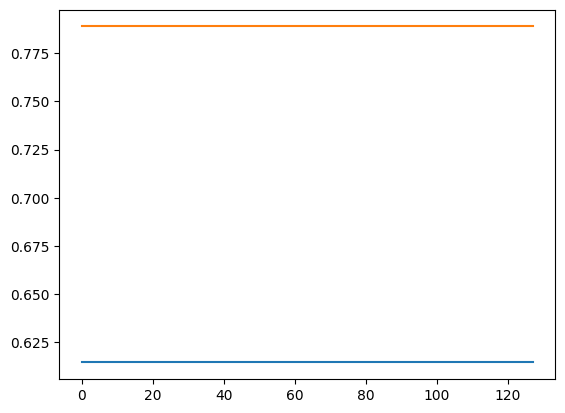

In [1257]:
print(Cs.shape)
plt.plot(np.real(Cs))
plt.show()

In [16]:
C_f, b_f = y_to_Cb(solver.y, num_mctdhf_orbitals, num_spin_orbitals, num_electrons)

h_tilde = np.einsum('pk, qj, kj -> pq', b_f.conj(), b_f, h)
g_tilde = np.einsum('pi, qj, rk, sl, ijkl -> pqrs', b_f.conj(), b_f.conj(), b_f, b_f, z)

D, d = get_RDMs(num_mctdhf_orbitals, num_electrons, C_f)

print(f"E={np.einsum('pq, pq', D, h_tilde) + 0.5 * np.einsum('pqrs, pqrs', g_tilde, d)}")

print(C_f)
print(b_f)
print(D)
print(h_tilde)
#print(h)

NameError: name 'solver' is not defined

In [17]:
b = b_f
#b = np.eye(num_mctdhf_orbitals, num_spin_orbitals)
#b = b_init

bc = b.conj()

h_1 = np.einsum('nk, jk -> nj', b, h)
h_2 = np.einsum('mj, nj -> nm', bc, h_1) # Fully transformed integral
h_3 = np.einsum('mj, mn -> nj', b, h_2)

g_2 = np.einsum('rk, sl, ijkl -> ijrs', bc, b, g)
g_3 = np.einsum('qj, ijrs -> iqrs', b, g_2)
g_4 = np.einsum('pi, iqrs -> pqrs', bc, g_3) # Fully transformed integral
g_5 = np.einsum('pi, pqrs -> iqrs', b, g_4)

#print(h_3)

D, d = get_RDMs(num_mctdhf_orbitals, num_electrons, C_init)

#print(b)
#print(g)

print(np.einsum('np, pqrs, kqrs -> nk', np.linalg.pinv(D, hermitian = True), d, g_3-g_5))

NameError: name 'b_f' is not defined

In [19]:
#mctdhf_fun = MCDTHF(h, g, num_mctdhf_orbitals, num_spin_orbitals, num_electrons)
mctdhf_fun = MCDTHF_imaginary_time(h, g, num_mctdhf_orbitals, num_spin_orbitals, num_electrons)

y_init = Cb_to_y(C_init, b_init)

Cs = np.copy(C_init).reshape(1,-1)

t_init = 0
dt=0.01

C = C_init
b = b_init.T
bc = b.conj()
#print(np.dot(bc[0,:],b[0,:]), np.dot(bc[0,:],b[1,:]))
print(bc.T@b)
print(b)
print(b.shape)

[[ 1.00000000e+00+0.j -2.65293101e-16+0.j]
 [-2.65293101e-16+0.j  1.00000000e+00+0.j]]
[[ 0.25782531+0.j  0.71211143+0.j]
 [ 0.95577939+0.j -0.28693203+0.j]
 [ 0.14146332+0.j  0.64075527+0.j]]
(3, 2)


In [20]:
# Normalize every step during imaginary time prop
#C = np.divide(C, np.sqrt(C.T.conj()@C))

def fun(t,b):
    b = b.reshape((num_spin_orbitals, num_mctdhf_orbitals))
    bc = b.conj()

    #h_1 = np.einsum('nk, jk -> nj', b, h)
    #h_2 = np.einsum('mj, nj -> nm', bc, h_1) # Fully transformed integral
    #h_3 = np.einsum('mj, nm -> nj', b, h_2)
    h_1 = h@b
    h_2 = b.conj().T@h_1
    h_3 = b@h_2

    #print(bc.T@b)

    #g_2 = np.einsum('rk, sl, ijkl -> ijrs', bc, b, g)
    #g_3 = np.einsum('qj, ijrs -> iqrs', b, g_2)
    #g_4 = np.einsum('pi, iqrs -> pqrs', bc, g_3) # Fully transformed integral
    #g_5 = np.einsum('pi, pqrs -> iqrs', b, g_4)

    #D, d = get_RDMs(num_mctdhf_orbitals, num_electrons, C)

    # Regularize
    #eps = 1e-3
    #D_reg = D + eps*expm(-D/eps)

    #H = SlaterCondonHamiltonian(num_mctdhf_orbitals, num_electrons, h_2, z).get_hamiltonian()

    #C_dot = -np.matmul(H,C)
    b_dot = -(h_1-h_3)# + np.einsum('np, pqrs, kqrs -> nk', np.linalg.pinv(D, hermitian = True), d, g_3-g_5))

    print(b.conj().T@b_dot)

    #C = C + dt*C_dot
    b = b + dt*b_dot
    b = np.divide(b, np.sqrt(np.einsum('ij, ij -> j', b.conj(), b)))
    bc = b.conj()

    #print(f"E = {np.einsum('pq, pq', D, h_2)}") # + 0.5 * np.einsum('pqrs, pqrs', g_4, d)}")
    #print(np.diag(h_2))


    #print(f"C =\n{C}")
    #print(f"b =\n{b}")
    #print(f"b_dot =\n{b_dot}")
    #print(np.dot(bc[0,:],b[0,:]), np.dot(bc[0,:],b[1,:]))
    #print(bc.T@b)

    return b_dot.flatten()

In [1261]:
class RK4:
    def __init__(self, rhs, y0, t0):
        self.rhs = rhs
        self.y = y0
        self.t = t0

    def integrate(self, t):
        dt = t - self.t

        k1 = self.rhs(self.t, self.y)
        k2 = self.rhs(self.t + dt / 2, self.y + dt * k1 / 2)
        k3 = self.rhs(self.t + dt / 2, self.y + dt * k2 / 2)
        k4 = self.rhs(self.t + dt, self.y + dt * k3)

        self.y += 1 / 6 * (k1 + 2 * k2 + 2 * k3 + k4) * dt
        self.t += dt

        return self.t, self.y


In [1368]:
rk4 = RK4(fun, b_init.T.flatten(), t_init)
t = t_init

In [1369]:
t = t + dt
_, b = rk4.integrate(t)
b = b.reshape((num_spin_orbitals, num_mctdhf_orbitals))
print(b.conj().T@b)

[[-2.17201485e-17+0.j  3.51241375e-16+0.j]
 [ 1.87434549e-16+0.j  2.36919324e-16+0.j]]
[[ 3.88540968e-06+0.j -8.69143388e-06+0.j]
 [-1.44275906e-05+0.j  3.22736751e-05+0.j]]
[[-3.78148912e-06+0.j  8.48600521e-06+0.j]
 [ 1.41254474e-05+0.j -3.16976128e-05+0.j]]
[[-2.00926900e-07+0.j  3.97808660e-07+0.j]
 [ 5.87904876e-07+0.j -1.12161094e-06+0.j]]
[[ 1.00000000e+00+0.j -4.55511657e-11+0.j]
 [-4.55511657e-11+0.j  1.00000000e+00+0.j]]


# Test

In [1358]:
num_fd_basis = len(x)-2

b_init = np.ones(num_fd_basis)/np.sqrt(num_fd_basis)

def h_finite_diff(grid, potential):
    num_grid_points = len(grid)

    # Assume even spacing
    dx = abs(grid[1] - grid[0])

    # Construct tridiagonal matrix (from finite-differences)
    h_diag = 1.0 / (dx**2) + potential(grid[1:-1])
    h_off_diag = -1.0 / (2 * dx**2) * np.ones(num_grid_points - 3)

    return np.diag(h_diag) + np.diag(h_off_diag, 1) + np.diag(h_off_diag, -1)

h_fd = h_finite_diff(x, pot)

def b_dot(t, b):
    b = b.reshape((num_fd_basis, 1))
    b_dot = - h_fd@b
    return b_dot.flatten()


In [1349]:
b_dot(0, b_init)

array([-4.10653535e+01, -1.57007327e+00, -1.56376776e+00, -1.55747494e+00,
       -1.55119480e+00, -1.54492735e+00, -1.53867259e+00, -1.53243052e+00,
       -1.52620113e+00, -1.51998444e+00, -1.51378042e+00, -1.50758910e+00,
       -1.50141046e+00, -1.49524451e+00, -1.48909125e+00, -1.48295067e+00,
       -1.47682278e+00, -1.47070758e+00, -1.46460507e+00, -1.45851524e+00,
       -1.45243810e+00, -1.44637365e+00, -1.44032188e+00, -1.43428280e+00,
       -1.42825641e+00, -1.42224271e+00, -1.41624169e+00, -1.41025336e+00,
       -1.40427772e+00, -1.39831476e+00, -1.39236449e+00, -1.38642691e+00,
       -1.38050201e+00, -1.37458981e+00, -1.36869029e+00, -1.36280345e+00,
       -1.35692931e+00, -1.35106785e+00, -1.34521908e+00, -1.33938299e+00,
       -1.33355960e+00, -1.32774888e+00, -1.32195086e+00, -1.31616553e+00,
       -1.31039288e+00, -1.30463292e+00, -1.29888564e+00, -1.29315105e+00,
       -1.28742915e+00, -1.28171994e+00, -1.27602341e+00, -1.27033957e+00,
       -1.26466842e+00, -

In [1359]:
rk4 = RK4(b_dot, b_init, 0)
_, b = rk4.integrate(0.001)

np.dot(b,b)

0.9675460886763877

In [1376]:
h_test = np.diag([0.5, 1.5, 2.5])
b_test = 1/np.sqrt(5)*np.array([[1,2],[1,0],[-2,1]])
print(h_test)
print(b_test)
print(b_test[:,0].T@b_test[:,0])

[[0.5 0.  0. ]
 [0.  1.5 0. ]
 [0.  0.  2.5]]
[[ 0.4472136   0.89442719]
 [ 0.4472136   0.        ]
 [-0.89442719  0.4472136 ]]
1.2
